In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [2]:
df=pd.read_csv('transactions_kaggle.csv')


In [3]:
df

,transaction_id,persona_id,date,description,amount,category,is_labelled
0,1,P01,01/09/2023,Balance brought forward,0.00,Excluded,True
1,2,P01,01/09/2023,DIRECT DEBIT BUPA AUSTRALIA DDR ID 098647,120.90,Essential,True
2,3,P01,01/09/2023,VISA PURCHASE HENRY COFFEE FORTITUDE VLY,6.19,Non-Essential,True
3,4,P01,02/09/2023,VISA PURCHASE SUSHI HUB CBD,9.11,Non-Essential,True
4,5,P01,02/09/2023,POS CAMPOS SOUTH BRISBANE TID 957282,6.29,Non-Essential,True
...,...,...,...,...,...,...,...
33863,33864,P10,30/08/2025,CARD PURCHASE 30AUG 7-ELEVEN 8440 SANDY BAY,8.52,NaN,False
33864,33865,P10,30/08/2025,EFTPOS PURCHASE DAILY GRIND BATTERY PT TID 974982,4.82,NaN,False
33865,33866,P10,31/08/2025,POS HARRIS FARM NORTH HOBART TID 244192,128.60,NaN,False
33866,33867,P10,31/08/2025,Total debits,146702.37,NaN,False


In [4]:
labelled = df[df['is_labelled'] == True].copy()
unlabelled = df[df['is_labelled'] == False].copy()

In [5]:
print("Label berilgan:", labelled.shape)
print("Label berilmagan:", unlabelled.shape)

Label berilgan: (5000, 7)
Label berilmagan: (28868, 7)


In [6]:
labelled['description'] = labelled['description'].fillna('')
unlabelled['description'] = unlabelled['description'].fillna('')


In [7]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

In [8]:
X_labelled = vectorizer.fit_transform(labelled['description'])

In [9]:
y_labelled = labelled['category']

In [10]:
X_unlabelled = vectorizer.transform(unlabelled['description'])

In [11]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_labelled, y_labelled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
predicted_category = model.predict(X_unlabelled)

In [13]:
predicted_category[:20]

array(['Non-Essential', 'Non-Essential', 'Non-Essential', 'Non-Essential',
       'Non-Essential', 'Non-Essential', 'Non-Essential', 'Non-Essential',
       'Excluded', 'Non-Essential', 'Non-Essential', 'Non-Essential',
       'Non-Essential', 'Non-Essential', 'Non-Essential', 'Non-Essential',
       'Non-Essential', 'Non-Essential', 'Non-Essential', 'Non-Essential'],
      dtype=object)

In [14]:
probabilities = model.predict_proba(X_unlabelled)

confidence = probabilities.max(axis=1)

In [15]:
confidence[:20]

array([0.96223506, 0.94589112, 0.98857273, 0.94276082, 0.96915221,
       0.94344094, 0.94235904, 0.974859  , 0.95264073, 0.94006368,
       0.97974871, 0.97969547, 0.95292191, 0.96508885, 0.96016177,
       0.92685295, 0.95488859, 0.951915  , 0.93748354, 0.95560606])

In [16]:
threshold = 0.80

high_confidence = confidence >= threshold

In [17]:
high_confidence.sum()

np.int64(28769)

In [18]:
unlabelled.loc[:, 'predicted_category'] = predicted_category
unlabelled.loc[:, 'confidence'] = confidence

In [19]:
pseudo_labelled = unlabelled[
    unlabelled['confidence'] >= threshold
].copy()

In [20]:
pseudo_labelled[['description', 'predicted_category', 'confidence']].head(20)

,description,predicted_category,confidence
500,CARD PURCHASE 15JAN DAILY GRIND 7407 SOUTH BRI...,Non-Essential,0.962235
501,VISA PURCHASE MAD MEX FORTITUDE VLY,Non-Essential,0.945891
502,CARD PURCHASE 16JAN ST DREUX 2649 CBD,Non-Essential,0.988573
503,VISA PURCHASE CAMPOS SOUTH BRISBANE,Non-Essential,0.942761
504,VISA PURCHASE RUBY COFFEE NEW FARM,Non-Essential,0.969152
505,VISA PURCHASE ROLLD SOUTH BRISBANE,Non-Essential,0.943441
506,CARD PURCHASE 17JAN 7-ELEVEN 1430 SOUTH BRISBANE,Non-Essential,0.942359
507,APPLE.COM/BILL AUS,Non-Essential,0.974859
508,PAYID FROM TAYLA S REF LUNCH,Excluded,0.952641
509,POS MECCA TOOWONG TID 844683,Non-Essential,0.940064


In [21]:
df['category_predicted'] = df['category']

In [22]:
df.loc[
    df['is_labelled'] == False,
    'category_predicted'
] = predicted_category

In [23]:
df[['description', 'category', 'category_predicted', 'is_labelled']].head(20)

,description,category,category_predicted,is_labelled
0,Balance brought forward,Excluded,Excluded,True
1,DIRECT DEBIT BUPA AUSTRALIA DDR ID 098647,Essential,Essential,True
2,VISA PURCHASE HENRY COFFEE FORTITUDE VLY,Non-Essential,Non-Essential,True
3,VISA PURCHASE SUSHI HUB CBD,Non-Essential,Non-Essential,True
4,POS CAMPOS SOUTH BRISBANE TID 957282,Non-Essential,Non-Essential,True
5,CARD PURCHASE 03SEP GOLDEN LOTUS 2452 CBD,Non-Essential,Non-Essential,True
6,VISA PURCHASE 7-ELEVEN NEW FARM,Non-Essential,Non-Essential,True
7,CARD PURCHASE 03SEP ST DREUX 9387 SOUTH BRISBANE,Non-Essential,Non-Essential,True
8,PAYROLL Harbour Media NET PAY,Excluded,Excluded,True
9,PAYID TRANSFER TO RENT BRISBANE 36 REF 22551,Essential,Essential,True


In [24]:
df.to_csv(
    "transactions_semi_supervised.csv",
    index=False
)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_labelled,
    y_labelled,
    test_size=0.2,
    random_state=42,
    stratify=y_labelled
)

In [27]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [30]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

    Essential       1.00      1.00      1.00       141
     Excluded       1.00      1.00      1.00        27
Non-Essential       1.00      1.00      1.00       832

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



In [31]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[141   0   0]
 [  0  27   0]
 [  0   0 832]]


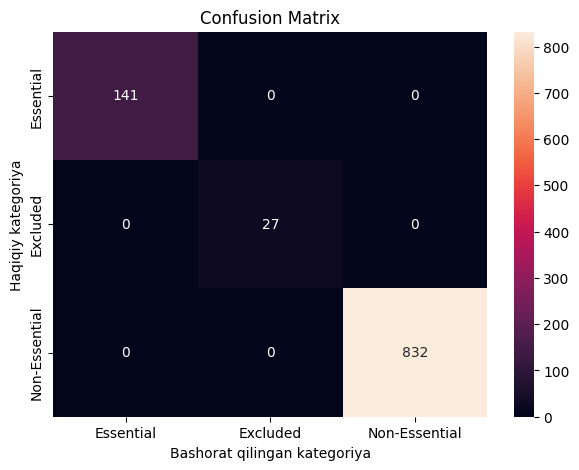

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Bashorat qilingan kategoriya")
plt.ylabel("Haqiqiy kategoriya")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
description = input("Transaction description kiriting: ")

description_tfidf = vectorizer.transform([description])

prediction = model.predict(description_tfidf)[0]

print("Bashorat:", prediction)

In [ ]:
description = input("Transaction description kiriting: ")

description_tfidf = vectorizer.transform([description])

prediction = model.predict(description_tfidf)[0]

if prediction == "Essential":
    print("Natija: MUHIM")
elif prediction == "Non-Essential":
    print("Natija: MUHIM EMAS")
elif prediction == "Excluded":
    print("Natija: HISOBGA OLINMAYDI")

In [ ]:
description = input("Transaction description kiriting: ")

description_tfidf = vectorizer.transform([description])

prediction = model.predict(description_tfidf)[0]

probability = model.predict_proba(description_tfidf).max()

if prediction == "Essential":
    natija = "MUHIM"
elif prediction == "Non-Essential":
    natija = "MUHIM EMAS"
else:
    natija = "HISOBGA OLINMAYDI"

print("Natija:", natija)
print("Model ishonchliligi:", round(probability * 100, 2), "%")